# Showcase — the Suez Canal blockage (Ever Given, March 2021)

On **23 March 2021** the 400 m container ship *Ever Given* ran aground and wedged across the Suez Canal, halting one of the world's busiest shipping lanes for six days until it was refloated on 29 March. This notebook pulls a Sentinel-2 time series around the blockage and renders it with **pyramids' own plotting** — `Dataset.plot()` for the true-colour scenes and `DatasetCollection.plot()` for the animation.

## What this notebook does

1. **Fetch** a Sentinel-2 true-colour scene for six dates spanning the blockage.
2. **Compare** before / during / after with `Dataset.plot(rgb_options=...)`.
3. **Animate** the stack with `DatasetCollection.plot()`.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`; the download cells skip gracefully without credentials.

In [1]:
import os, tempfile, base64
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from loguru import logger
from IPython.display import HTML, display
from earthlens import EarthLens
from pyramids.dataset import Dataset, DatasetCollection   # pyramids' own plotting

logger.disable("earthlens"); logger.disable("pyramids")
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

def grab(collection, aoi, start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start, end]; return its GeoTIFF path or None."""
    el = EarthLens(data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={collection: list(bands)}, lat_lim=[aoi[1], aoi[3]], lon_lim=[aoi[0], aoi[2]],
        path=tempfile.mkdtemp(), scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001
        print("download skipped (needs GEE credentials):", exc); return None
    return str(p[0]) if p else None

def animate_collection(files, band, title, cmap=None, fps=1):
    """Animate a stack of GeoTIFFs with pyramids DatasetCollection.plot; embed as GIF."""
    glyph = DatasetCollection.from_files(files).plot(band=band, title=title, cmap=cmap)
    gif = os.path.join(tempfile.mkdtemp(), "anim.gif")
    glyph.save_animation(gif, fps=fps)
    return HTML(f'<img src="data:image/gif;base64,{base64.b64encode(open(gif,"rb").read()).decode()}" style="max-width:620px"/>')

AOI = [32.570, 30.005, 32.592, 30.030]; C = "COPERNICUS/S2_SR_HARMONIZED"
DATES = ["2021-03-04", "2021-03-19", "2021-03-24", "2021-03-29", "2021-04-03", "2021-04-13"]

# One true-colour scene per date; keep the file paths so we can build a
# DatasetCollection for the animation.
files, labels = [], []
for d in DATES:
    p = grab(C, AOI, d, d, ["B4", "B3", "B2"], scale=10)
    if p:
        files.append(p); labels.append(d)
print(f"{len(files)} scenes:", labels)

6 scenes: ['2021-03-04', '2021-03-19', '2021-03-24', '2021-03-29', '2021-04-03', '2021-04-13']


## Before / during / after — `Dataset.plot()`

Each scene is rendered with pyramids' `Dataset.plot(rgb_options=...)`, which percentile-stretches the R/G/B bands and draws geographic axes. The 19 Mar canal flows normally; on 24 Mar the *Ever Given* is wedged across it; by 3 Apr traffic is moving again.

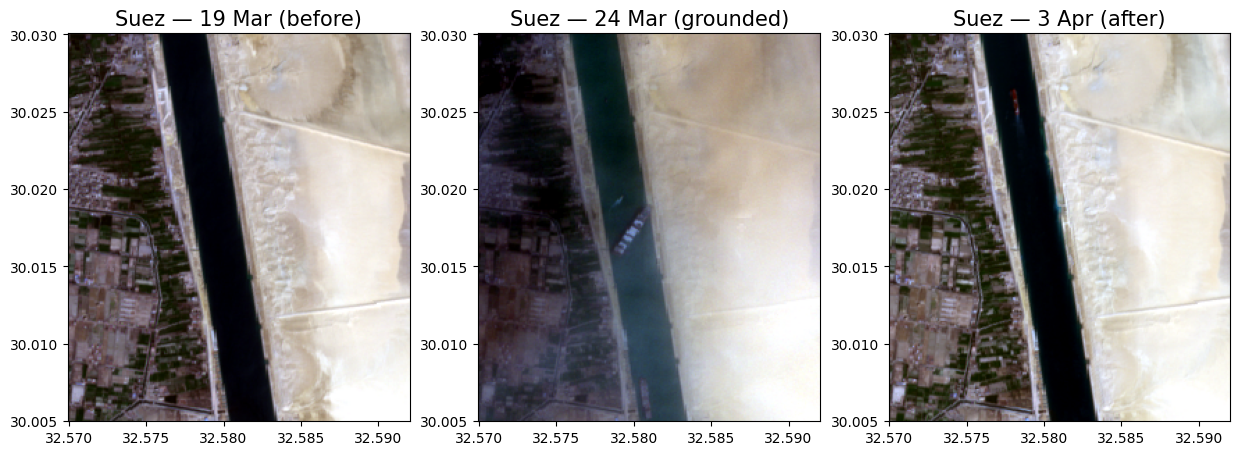

In [2]:
# pyramids Dataset.plot for each chosen scene, drawn into a shared figure.
pick = {"19 Mar (before)": "2021-03-19", "24 Mar (grounded)": "2021-03-24", "3 Apr (after)": "2021-04-03"}
have = dict(zip(labels, files))
sel = [(t, have[d]) for t, d in pick.items() if d in have]
if sel:
    fig, axes = plt.subplots(1, len(sel), figsize=(5 * len(sel), 6))
    axes = np.atleast_1d(axes)
    for ax, (t, path) in zip(axes, sel):
        Dataset.read_file(path).plot(rgb_options={"rgb": [0, 1, 2], "percentile": 2},
                                     ax=ax, title=f"Suez — {t}")
    plt.show()
else:
    print("no scenes — set GEE credentials and rerun")

## Animated sequence — `DatasetCollection.plot()`

pyramids stacks the scenes and animates one band across time (the red band here); the ship appears in the channel, then clears.


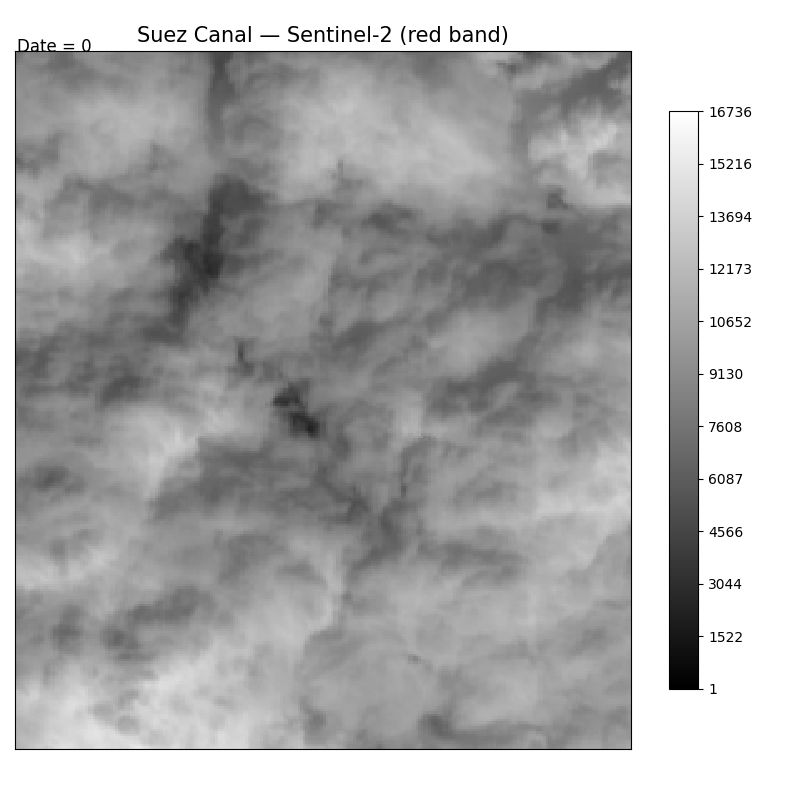

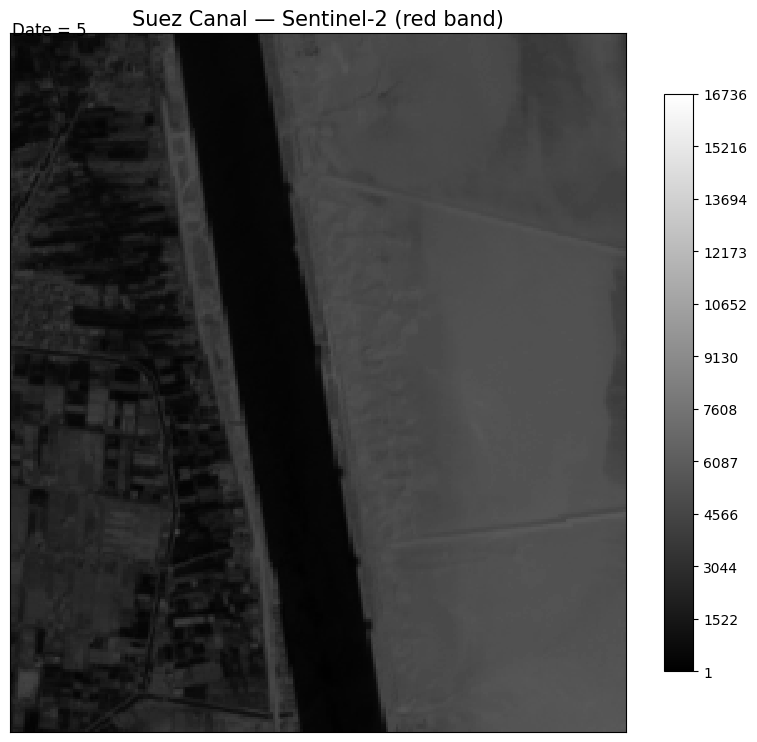

In [3]:
if files:
    display(animate_collection(files, band=0, title="Suez Canal — Sentinel-2 (red band)", cmap="gray", fps=1))
else:
    print("no scenes to animate")

## Recap

The satellite scenes are rendered entirely through pyramids — `Dataset.plot()` for the stills (with geographic axes) and `DatasetCollection.plot()` for the animation — so earthlens hands the bytes to pyramids and pyramids does the cartography.

## Try it yourself

- Change `DATES`/`AOI`, or animate a different `band`.
- See the [GEE backend reference](../../reference/gee/introduction.md) and the pyramids `Dataset`/`DatasetCollection` plotting docs.